# A3 — Classificador com CNN pré-treinada (transfer learning por feature extraction)

**Como executar:** Google Colab com GPU T4 (*Ambiente de execução > Alterar o tipo de ambiente de
execução > T4 GPU*) e *Executar tudo*. Um único treino: só o novo head de classificação, com o
backbone congelado.

| | Execução completa |
|---|---|
| Tempo estimado de execução | ~2 min (124 s medidos, incluindo o download dos pesos da ResNet-50, com o dataset vindo do cache do Colab; sem esse cache, somar o download do dataset, ~1 GB compactado) |
| Pico de VRAM alocada (reservada) | 0,80 GB (1,25 GB), na extração das features |
| Pico de RAM do processo | 1,9 GB |

> Medido no Colab T4 em 04/10/2026: tabela de tempo e memória no apêndice (detalhe por etapa em
> `report_assets/tempos_execucao.csv`). **VRAM alocada** = memória dos tensores do PyTorch; a
> **reservada** inclui o cache do alocador e fica mais perto do `nvidia-smi`; nenhuma inclui o contexto
> CUDA. A RAM é o pico do processo (`ru_maxrss`). O treino do head em si leva ~2 s.

## Setup

Clone do código (`src/`), pasta de saída, imports e configuração. O código dos módulos está no
repositório; o notebook só orquestra.

In [1]:
import os
import subprocess
import time

_T_INICIO_NOTEBOOK = time.perf_counter()  # tempo total do notebook (R15)
TEMPOS = []  # registro das etapas cronometradas

REPO_URL = "https://github.com/anacaetano02/Deep-Learning-Visao-Computacional.git"
SUBPASTA = "A3_cnn_kaggle"
REPO_DIR = "/content/repo"
# Versão do código: a tag da versão entregue fixa o src/ e o split que geraram os resultados (os
# commits seguintes do repositório, das outras atividades, não mudam esta execução). None = branch principal.
GIT_REF = "a3-entrega"

PROJECT_DIR = os.path.join(REPO_DIR, SUBPASTA)

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    # --filter=blob:none + --sparse: baixa só os arquivos da pasta da A3, não o repositório inteiro
    ref = ["--branch", GIT_REF] if GIT_REF else []
    subprocess.run(["git", "clone", "--filter=blob:none", "--sparse", "--depth", "1", *ref, REPO_URL, REPO_DIR],
                   check=True)
    subprocess.run(["git", "sparse-checkout", "set", SUBPASTA], cwd=REPO_DIR, check=True)
else:
    # Já clonado nesta sessão (talvez por outro notebook): garante a pasta da A3 no sparse checkout
    subprocess.run(["git", "sparse-checkout", "add", SUBPASTA], cwd=REPO_DIR, check=True)
    if GIT_REF:
        # Garante a versão fixada (não puxa commits novos)
        subprocess.run(["git", "fetch", "--depth", "1", "origin", "tag", GIT_REF], cwd=REPO_DIR, check=True)
        subprocess.run(["git", "checkout", GIT_REF], cwd=REPO_DIR, check=True)
    else:
        print(f"Repositório já clonado em '{REPO_DIR}': buscando mudanças mais recentes...")
        subprocess.run(["git", "pull"], cwd=REPO_DIR, check=True)

TEMPOS.append({"etapa": "clone/pull do repositório", "segundos": round(time.perf_counter() - _T_INICIO_NOTEBOOK, 1)})

In [2]:
import importlib, sys

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

# Ao reexecutar o notebook na mesma sessão depois de atualizar o código, recarrega os módulos src.*
# já importados. Num runtime novo não há nada para recarregar e a célula não faz nada.
for nome in sorted(m for m in sys.modules if m == "src" or m.startswith("src.")):
    importlib.reload(sys.modules[nome])

In [3]:
# Onde salvar os artefatos desta execução (split, features, checkpoint do head, tabelas, figuras).
# * False (padrão): disco local do Colab, em /content (apagado quando o runtime é desconectado).
# * True: Google Drive (pede autorização no início).
from pathlib import Path

SALVAR_NO_DRIVE = False

if SALVAR_NO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/deep_learning_visao_computacional/A3_cnn_kaggle")
else:
    BASE_DIR = Path("/content/A3_cnn_kaggle_saida")

DIR_DADOS = BASE_DIR / "data"
DIR_OUTPUTS = BASE_DIR / "outputs"
DIR_REPORT_ASSETS = DIR_OUTPUTS / "report_assets"   # tabelas e figuras que vão para o relatório

for d in (DIR_DADOS, DIR_REPORT_ASSETS):
    d.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR = {BASE_DIR} (Drive: {SALVAR_NO_DRIVE})")

BASE_DIR = /content/A3_cnn_kaggle_saida (Drive: False)


In [4]:
# Configuração do experimento (cada escolha é justificada nos markdowns das seções)
SEED = 42
MODELO_BACKBONE = "resnet50"        # torchvision
PESOS_BACKBONE = "IMAGENET1K_V2"    # versão dos pesos do ImageNet (fixa os pesos, como o SHA na A2)
FRACOES_SPLIT = (0.70, 0.15, 0.15)  # treino / validação / teste, estratificado por classe

# Treino do head (um único treino; valores fixados antes de ver o teste e idênticos aos da 1ª execução)
CONFIG_TREINO = {
    "otimizador": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epocas": 40,
    "tamanho_lote": 64,
    "pesos_de_classe": "balanced",     # n_treino / (n_classes × n_treino_da_classe), só no treino
    "selecao": "menor val_loss",
}

## Dados: Kaggle `pavansanagapati/images-dataset` (R1)

**Origem.** Dataset do Kaggle `pavansanagapati/images-dataset`, **versão 1** (a única), licença CC0,
baixado com o `kagglehub`. A versão é garantida pela **impressão digital** conferida por `assert`
(3.606 arquivos, 1.508,4 MB, assinatura `1d9391889f4f5ae0`): ela vale tanto para o download quanto para
o cache do Colab, cujo caminho não mostra a versão. A impressão digital usa nomes e tamanhos dos
arquivos; quem confere o conteúdo é o md5, na comparação das cópias e na busca de duplicatas.

**Estrutura.** O dataset traz **duas cópias** das mesmas imagens, `data/<classe>/` e
`data/data/<classe>/`, com 1.803 imagens cada. A comparação por nome e md5 mostrou que são **idênticas**
(0 arquivos só numa delas, 0 com conteúdo diferente): só `data/` é usada. Com as duas, a mesma foto
cairia no treino e no teste.

**7 classes**, com o número de imagens em cada estágio:

| Classe | Bruto (uma cópia) | Após duplicatas exatas (md5) | Corpus final (após quase-duplicatas) |
|---|---|---|---|
| bike | 365 | 364 | 358 |
| cars | 420 | 420 | 418 |
| cats | 202 | 202 | 202 |
| dogs | 202 | 202 | 201 |
| flowers | 210 | 210 | 210 |
| horses | 202 | 183 | 178 |
| human | 202 | 183 | 177 |
| **Total** | **1.803** | **1.764** | **1.744** |

No corpus final, a maior classe (cars, 418) tem ~2,4× a menor (human, 177).

**O que a EDA mostrou e importa para a análise:**
- **Formato, resolução e modo de cor coincidem com a classe:** bike e cars são BMP 640×480 (cenas de rua
  de Graz); flowers são PNG 128×128 em RGBA (o alfa é sempre opaco: a composição sobre fundo branco não
  muda nenhuma imagem); cats, dogs, horses e human são JPG de tamanhos variados (horses e human com
  mediana de ~200–260 px). Uma CNN pode usar essas pistas técnicas como atalho, e o teste tem o mesmo viés.
- **human são cavaleiros** (arquivos `rider-*`), às vezes com o cavalo na foto: é o par de classes com
  mais risco de confusão de rótulo.

In [5]:
import kagglehub

from src.dados import ASSINATURA_DATASET, N_ARQUIVOS_DATASET, VERSAO_DATASET, impressao_digital

# Download com a versão fixada. No Colab, o kagglehub pode servir o cache do próprio Colab
# (/kaggle/input/...), cujo caminho não mostra a versão: quem garante que os dados são os mesmos é a
# impressão digital (nº de arquivos + hash da lista caminho|tamanho).
_t0 = time.perf_counter()
DIR_DATASET = Path(kagglehub.dataset_download(f"pavansanagapati/images-dataset/versions/{VERSAO_DATASET}"))
TEMPOS.append({"etapa": "download do dataset", "segundos": round(time.perf_counter() - _t0, 1)})
print(DIR_DATASET)

n_arquivos, mb, assinatura = impressao_digital(DIR_DATASET)
assert (n_arquivos, assinatura) == (N_ARQUIVOS_DATASET, ASSINATURA_DATASET), "O conteúdo do dataset mudou"
print(f"{n_arquivos} arquivos, {mb} MB, assinatura {assinatura}")

Using Colab cache for faster access to the 'images-dataset' dataset.
/kaggle/input/images-dataset
3606 arquivos, 1508.4 MB, assinatura 1d9391889f4f5ae0


In [6]:
from collections import Counter

from src.dados import PASTA_COPIA, PASTA_COPIA_DUPLICADA, arvore, comparar_copias

arvore(DIR_DATASET)
print("Extensões:", Counter(p.suffix.lower() for p in DIR_DATASET.rglob("*") if p.is_file()).most_common())

# As duas cópias (data/ e data/data/) têm os mesmos arquivos com o mesmo conteúdo? Se sim, só uma é
# usada: com as duas, a mesma foto cairia no treino e no teste (vazamento, como na A1).
copias = comparar_copias(DIR_DATASET)
print(f"{PASTA_COPIA}/: {copias['na_copia']} imagens · {PASTA_COPIA_DUPLICADA}/: {copias['na_duplicada']} · "
      f"só numa delas: {len(copias['so_na_copia']) + len(copias['so_na_duplicada'])} · "
      f"mesmo nome com conteúdo diferente: {len(copias['conteudo_diferente'])}")
assert not (copias["so_na_copia"] or copias["so_na_duplicada"] or copias["conteudo_diferente"]), copias
print(f"As duas cópias são idênticas: só {PASTA_COPIA}/ é usada.")

data/  (3606 arquivos)
    bike/  (365 arquivos)
    cars/  (420 arquivos)
    cats/  (202 arquivos)
    data/  (1803 arquivos)
        bike/  (365 arquivos)
        cars/  (420 arquivos)
        cats/  (202 arquivos)
        dogs/  (202 arquivos)
        flowers/  (210 arquivos)
        horses/  (202 arquivos)
        human/  (202 arquivos)
    dogs/  (202 arquivos)
    flowers/  (210 arquivos)
    horses/  (202 arquivos)
    human/  (202 arquivos)
Extensões: [('.jpg', 1616), ('.bmp', 1570), ('.png', 420)]
data/: 1803 imagens · data/data/: 1803 · só numa delas: 0 · mesmo nome com conteúdo diferente: 0
As duas cópias são idênticas: só data/ é usada.


In [7]:
import pandas as pd
from PIL import Image

from src.dados import CLASSES, carregar_imagem, listar_imagens, remover_duplicatas

imagens_brutas = listar_imagens(DIR_DATASET)
assert sorted(imagens_brutas["classe"].unique()) == CLASSES, imagens_brutas["classe"].unique()
print(f"{len(imagens_brutas)} imagens na cópia usada, {imagens_brutas['classe'].nunique()} classes")

# Duplicatas exatas (md5) dentro da cópia: mesma classe -> fica a primeira; classes diferentes ->
# conflito de rótulo, todas as cópias saem. Precisa ser feito ANTES do split: se ficassem, uma cópia
# poderia cair no treino e a outra no teste.
imagens, duplicadas, conflitos = remover_duplicatas(imagens_brutas)
print(f"Duplicatas exatas: {len(duplicadas)} arquivos em {duplicadas['md5'].nunique()} grupos; "
      f"conflitos de classe: {len(conflitos)}")
if len(duplicadas):
    display(duplicadas.groupby("md5")["caminho_rel"].apply(list).reset_index(drop=True).to_frame("arquivos iguais"))
imagens["caminho"] = [str(DIR_DATASET / c) for c in imagens["caminho_rel"]]
print(f"Imagens após remover duplicatas: {len(imagens)}")

1803 imagens na cópia usada, 7 classes
Duplicatas exatas: 78 arquivos em 39 grupos; conflitos de classe: 0


,arquivos iguais
0,"[data/human/rider-70.jpg, data/human/rider-89...."
1,"[data/human/rider-133.jpg, data/human/rider-49..."
2,"[data/human/rider-113.jpg, data/human/rider-96..."
3,"[data/bike/bike_163.bmp, data/bike/bike_199.bmp]"
4,"[data/horses/horse-112.jpg, data/horses/horse-..."
5,"[data/horses/horse-138.jpg, data/horses/horse-..."
6,"[data/horses/horse-51.jpg, data/horses/horse-5..."
7,"[data/human/rider-148.jpg, data/human/rider-54..."
8,"[data/human/rider-163.jpg, data/human/rider-19..."
9,"[data/human/rider-140.jpg, data/human/rider-98..."


Imagens após remover duplicatas: 1764


Imagens por classe (desbalanceamento: maior / menor = 2.3x):


,imagens
classe,
bike,364
cars,420
cats,202
dogs,202
flowers,210
horses,183
human,183


Formato do arquivo × classe:


formato,BMP,JPEG,PNG
classe,,,
bike,364,0,0
cars,420,0,0
cats,0,202,0
dogs,0,202,0
flowers,0,0,210
horses,0,183,0
human,0,183,0


Modo de cor × classe:


modo,RGB,RGBA
classe,,
bike,364,0
cars,420,0
cats,202,0
dogs,202,0
flowers,0,210
horses,183,0
human,183,0


Com pixel transparente (compostos sobre fundo branco): 0
Tamanho (px) por classe:


largura                                                   altura  \
          count   mean    std    min    25%    50%    75%     max  count   
classe                                                                     
bike      364.0  632.0   36.0  480.0  640.0  640.0  640.0   640.0  364.0   
cars      420.0  638.0   16.0  480.0  640.0  640.0  640.0   640.0  420.0   
cats      202.0  408.0  107.0   80.0  329.0  460.0  499.0   500.0  202.0   
dogs      202.0  396.0  117.0   98.0  300.0  440.0  499.0   500.0  202.0   
flowers   210.0  128.0    6.0  128.0  128.0  128.0  128.0   208.0  210.0   
horses    183.0  307.0  257.0  152.0  240.0  259.0  283.0  1920.0  183.0   
human     183.0  206.0   97.0   88.0  183.0  188.0  225.0  1302.0  183.0   

                                                           
          mean    std    min    25%    50%    75%     max  
classe                                                     
bike     488.0   36.0  480.0  480.0  480.0  480.0   640.0  
cars     482.0   16.0  480.0  480.0  480.0  480.0   640.0  
cats     355.0   96.0   89.0  301.0  374.0  400.0   500.0  
dogs     357.0   95.0   95.0  295.0  374.0  400.0   500.0  
flowers  128.0    6.0  128.0  128.0  128.0  128.0   208.0  
horses   234.0  151.0  115.0  183.0  194.0  225.0  1200.0  
human    265.0  151.0  144.0  225.0  256.0  275.0  2048.0

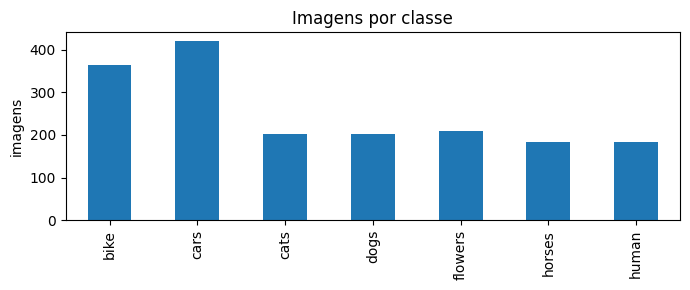

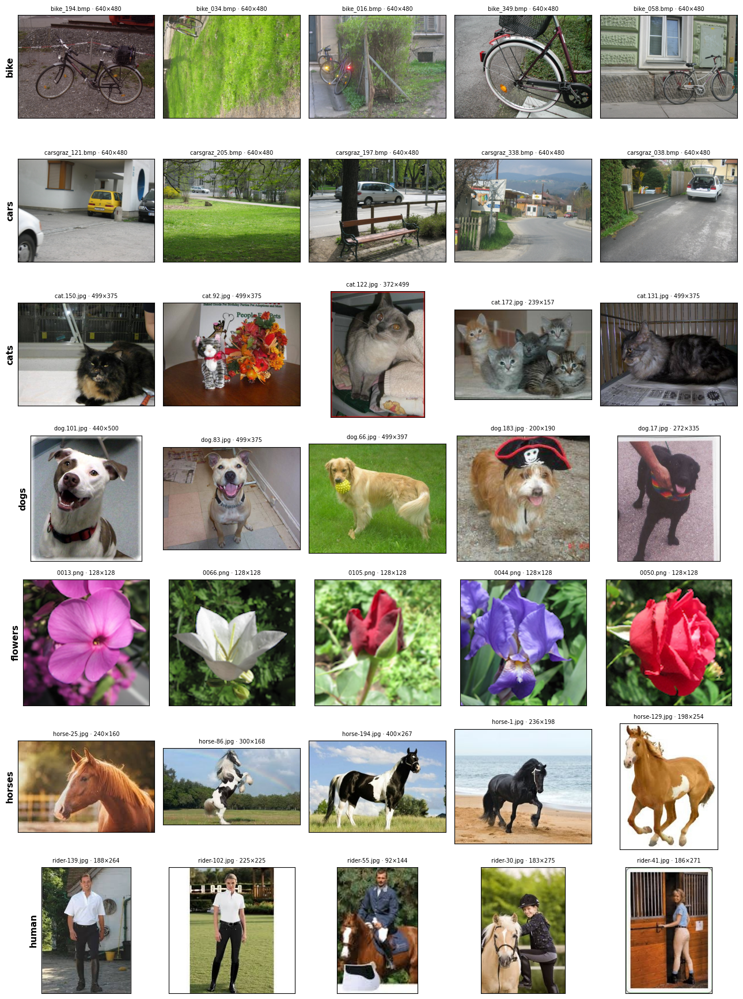

In [8]:
import matplotlib.pyplot as plt

# EDA: o que importa para a CNN e para a análise (R10–R13)
por_classe = imagens["classe"].value_counts().reindex(CLASSES)
print("Imagens por classe (desbalanceamento: maior / menor =",
      f"{por_classe.max() / por_classe.min():.1f}x):")
display(por_classe.to_frame("imagens"))

# Formato do arquivo × classe: se cada classe tiver um formato próprio, o formato (e os artefatos de
# compressão JPEG × BMP sem perda) pode servir de atalho para a classe.
print("Formato do arquivo × classe:")
display(pd.crosstab(imagens["classe"], imagens["formato"]))
print("Modo de cor × classe:")
display(pd.crosstab(imagens["classe"], imagens["modo"]))
print(f"Com pixel transparente (compostos sobre fundo branco): {int(imagens['transparente'].sum())}")

print("Tamanho (px) por classe:")
display(imagens.groupby("classe")[["largura", "altura"]].describe().round(0))

fig, ax = plt.subplots(figsize=(7, 3))
por_classe.plot.bar(ax=ax)
ax.set(title="Imagens por classe", xlabel="", ylabel="imagens")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "imagens_por_classe.png", dpi=150)
plt.show()

# 5 exemplos sorteados por classe
N_EXEMPLOS = 5
exemplos = imagens.groupby("classe").sample(n=N_EXEMPLOS, random_state=SEED)
fig, eixos = plt.subplots(len(CLASSES), N_EXEMPLOS, figsize=(2.6 * N_EXEMPLOS, 2.5 * len(CLASSES)))
for i, classe in enumerate(CLASSES):
    for k, (_, r) in enumerate(exemplos[exemplos["classe"] == classe].iterrows()):
        ax = eixos[i, k]
        ax.imshow(carregar_imagem(r["caminho"]))
        ax.set_title(f"{r['arquivo']} · {r['largura']}×{r['altura']}", fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
    eixos[i, 0].set_ylabel(classe, fontsize=11, fontweight="bold")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "exemplos_por_classe.png", dpi=110)
plt.show()

## Modelo pré-treinado (R2, R3)

**ResNet-50 com os pesos `IMAGENET1K_V2` do torchvision** (25,6 M parâmetros, 4,1 GFLOPs por imagem,
98 MB; 80,9% de top-1 no ImageNet-1K). Por que este backbone:
- **Domínio:** as sete classes são objetos do dia a dia que o ImageNet-1K cobre bem (há classes de
  bicicleta, vários tipos de carro, raças de cão e de gato, margarida e cavalo), então as features do
  pré-treino devem transferir quase diretamente.
- **Tamanho do dataset:** ~1.200 imagens de treino é pouco para ajustar milhões de parâmetros; um
  backbone forte e congelado com head linear treina só 14.343.
- **Número de classes:** 7 classes só definem o tamanho do head (2048 → 7); não pedem um backbone maior.
- **Colab T4:** o custo é pequeno: a extração das features das 1.764 imagens levou ~12 s, com pico de
  0,80 GB de VRAM.
- **Alternativa considerada:** EfficientNet-B0 (5,3 M parâmetros, 77,7% de top-1), mais leve. Como o
  custo é irrelevante neste tamanho de dataset, a escolha foi pela qualidade das features e pela
  simplicidade do head (`fc`). Os pesos V2 vêm de uma receita de treino mais moderna e trazem as próprias
  transforms (resize 232, crop 224).

In [9]:
import torch

from src.modelo import carregar_backbone

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def pico_vram_etapa() -> dict:
    """Picos de VRAM (GB) desde o último reset_peak_memory_stats: alocada (tensores do PyTorch) e
    reservada (inclui o cache do alocador; mais perto do nvidia-smi). Vazio na CPU."""
    if DEVICE != "cuda":
        return {}
    return {"pico_vram_gb": round(torch.cuda.max_memory_allocated() / 1e9, 2),
            "pico_vram_reservada_gb": round(torch.cuda.max_memory_reserved() / 1e9, 2)}


# Backbone pré-treinado no ImageNet e as transforms que vêm com os próprios pesos
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
_t0 = time.perf_counter()
modelo, pesos, TRANSFORM = carregar_backbone(MODELO_BACKBONE, PESOS_BACKBONE)
modelo = modelo.to(DEVICE)
TEMPOS.append({"etapa": "carregamento do backbone", "segundos": round(time.perf_counter() - _t0, 1),
               **pico_vram_etapa()})

meta = pesos.meta
metricas = meta["_metrics"]["ImageNet-1K"]
print(f"{MODELO_BACKBONE} ({PESOS_BACKBONE}): {meta['num_params'] / 1e6:.1f}M parâmetros, "
      f"ImageNet-1K top-1 {metricas['acc@1']:.1f}% / top-5 {metricas['acc@5']:.1f}%, "
      f"{meta['_ops']:.2f} GFLOPs por imagem, {meta['_file_size']:.0f} MB")
print(f"Head original: {modelo.fc} (as {len(meta['categories'])} classes do ImageNet)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


resnet50 (IMAGENET1K_V2): 25.6M parâmetros, ImageNet-1K top-1 80.9% / top-5 95.4%, 4.09 GFLOPs por imagem, 98 MB
Head original: Linear(in_features=2048, out_features=1000, bias=True) (as 1000 classes do ImageNet)


### Normalização (R12)

A entrada passa pelas transforms que vêm com os pesos: resize do menor lado para 232 px, center crop de
224 e normalização com a média μ = [0,485; 0,456; 0,406] e o desvio σ = [0,229; 0,224; 0,225] do
ImageNet. São os valores da distribuição em que o backbone foi treinado; como ele fica congelado, a
entrada precisa estar nessa mesma escala. Nada é calculado nos nossos dados, então não há vazamento do
teste. A discussão completa (e o que a normalização não resolve) está em "Normalização (R12, R13)", na
análise.

In [10]:
from torch.utils.data import DataLoader

from src.modelo import DatasetImagens

# Pré-processamento = transforms dos pesos: resize do menor lado, center crop e normalização com a
# média/desvio do ImageNet. Nada é calculado nos nossos dados (sem risco de vazamento do teste) e a
# entrada fica na mesma distribuição que o backbone viu no pré-treino (R12).
print(TRANSFORM)
RESOLUCAO = TRANSFORM.crop_size[0]

TAMANHO_LOTE = 64
NUM_WORKERS = 2  # vCPUs do Colab
# Features de TODAS as imagens (antes do split): o backbone é fixo e não é ajustado nos nossos dados,
# então extrair antes de dividir não vaza nada; e as features servem para achar quase-duplicatas no
# corpus inteiro. shuffle=False: a linha i das features é a linha i de `imagens`.
imagens = imagens.reset_index(drop=True)
dataset_todas = DatasetImagens(imagens, TRANSFORM, CLASSES)
loader_todas = DataLoader(dataset_todas, batch_size=TAMANHO_LOTE, shuffle=False, num_workers=NUM_WORKERS)

x0, y0 = dataset_todas[0]
assert tuple(x0.shape) == (3, RESOLUCAO, RESOLUCAO), tuple(x0.shape)
print(f"Entrada da rede: {tuple(x0.shape)} · {len(dataset_todas)} imagens")

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
Entrada da rede: (3, 224, 224) · 1764 imagens


## Feature extraction: backbone congelado e novo head (R4, R5)

- **Congelado:** todo o backbone. Congelar exige duas coisas: `requires_grad=False` (o otimizador não
  altera os pesos) **e** `eval()` (o BatchNorm usa as estatísticas do pré-treino; em `train()`, ele
  atualizaria `running_mean` e `running_var` a cada lote, e o backbone mudaria sem nenhum gradiente).
  Os asserts abaixo conferem as duas coisas nas 53 camadas de BatchNorm.
- **Treinado:** só o novo head, `Linear(2048, 7)`, no lugar do `fc` de 1.000 classes do ImageNet:
  **14.343 parâmetros** (2048 × 7 + 7), 0,061% do total.
- **Features em cache:** como o backbone é fixo e não há augmentation, as features de cada imagem são
  sempre as mesmas. Por isso elas são extraídas uma vez (para as 1.764 imagens, antes do split) e o head
  é treinado sobre elas. O assert `modelo(imagem) == head(features)` mostra que isso é equivalente a
  treinar o modelo inteiro com o backbone congelado. Extrair antes do split não vaza nada, porque o
  backbone não é ajustado nos nossos dados.
- **Seed** do PyTorch fixada antes de criar o head, para a inicialização ser reprodutível.

In [11]:
from torch import nn

from src.modelo import backbone_sem_head, preparar_feature_extraction

# Seed do PyTorch antes de criar o head: a inicialização dos pesos do Linear (e, no treino, a ordem
# dos lotes) fica reprodutível. SEED sozinho só controla o split e a amostra da EDA.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Feature extraction: backbone congelado (requires_grad=False + eval) e head novo Linear(2048, 7)
contagem = preparar_feature_extraction(modelo, n_classes=len(CLASSES))
modelo = modelo.to(DEVICE)   # o head novo nasce na CPU
extrator = backbone_sem_head(modelo)   # mesmo objeto, compartilha os pesos: imagem -> vetor de 2048
print(f"Novo head: {modelo.fc}")
print(f"Parâmetros: {contagem['total']:,} no total · {contagem['congelados']:,} congelados · "
      f"{contagem['treinaveis']:,} treináveis ({100 * contagem['treinaveis'] / contagem['total']:.3f}%)")

Novo head: Linear(in_features=2048, out_features=7, bias=True)
Parâmetros: 23,522,375 no total · 23,508,032 congelados · 14,343 treináveis (0.061%)


In [12]:
from src.modelo import extrair_features

# Verificações (R4, R5): só o head é treinável e o backbone fica em eval (BatchNorm congelado)
n_features = contagem["n_features"]
assert contagem["treinaveis"] == n_features * len(CLASSES) + len(CLASSES), contagem
assert all(not p.requires_grad for nome, p in modelo.named_parameters() if not nome.startswith("fc."))
assert all(p.requires_grad for p in modelo.fc.parameters())
camadas_bn = [m for m in modelo.modules() if isinstance(m, nn.BatchNorm2d)]
assert camadas_bn and not any(m.training for m in camadas_bn), "BatchNorm do backbone fora do eval"
print(f"OK: {contagem['treinaveis']:,} treináveis = {n_features} × {len(CLASSES)} + {len(CLASSES)} (só o head); "
      f"{len(camadas_bn)} camadas de BatchNorm em eval")

# Extração das features de todas as imagens (uma vez só: backbone fixo, sem augmentation)
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
_t0 = time.perf_counter()
FEATURES_TODAS, ROTULOS_TODAS = extrair_features(extrator, loader_todas, DEVICE)
TEMPOS.append({"etapa": "extração das features", "segundos": round(time.perf_counter() - _t0, 1),
               **pico_vram_etapa()})
assert FEATURES_TODAS.shape == (len(imagens), n_features), FEATURES_TODAS.shape
print(f"Features: {tuple(FEATURES_TODAS.shape)} em {TEMPOS[-1]['segundos']} s")
# Salvas por imagem (caminho_rel), não por split: o split é derivado depois, do CSV
torch.save({"caminho_rel": imagens["caminho_rel"].tolist(), "features": FEATURES_TODAS, "rotulos": ROTULOS_TODAS},
           DIR_OUTPUTS / "features.pt")

# Equivalência: modelo(imagem) == head(features), ou seja, treinar o head sobre as features é o mesmo
# que treinar o modelo inteiro com o backbone congelado
x_lote, _ = next(iter(loader_todas))
with torch.inference_mode():
    assert torch.allclose(modelo(x_lote.to(DEVICE)), modelo.fc(extrator(x_lote.to(DEVICE))), atol=1e-4)
print("OK: modelo(imagem) == head(features)")

OK: 14,343 treináveis = 2048 × 7 + 7 (só o head); 53 camadas de BatchNorm em eval
Features: (1764, 2048) em 11.9 s
OK: modelo(imagem) == head(features)


## Quase-duplicatas e split final (R1)

O md5 só pega cópias idênticas byte a byte. A mesma foto redimensionada ou recomprimida tem outro md5,
e uma cópia no treino com a outra no teste seria vazamento. Por isso, as features da ResNet-50 foram usadas
para comparar **todos os pares do corpus** (cosseno). Nas 1.764 imagens: 21 pares com cosseno ≥ 0,95,
54 ≥ 0,93 e 192 ≥ 0,90.

**Critério, decidido por inspeção visual das figuras (sem usar o desempenho do modelo):**
- **limiar 0,95:** acima dele, quase todos os pares são a mesma foto (ex.: `bike_300` × `bike_348`, com
  cosseno 1,000; `dog.74` × `dog.180`; vários `rider-*`);
- **6 exceções** acima do limiar que são fotos diferentes: cinco pares de margaridas e `horse-74` ×
  `horse-77`. Sem as exceções, o encadeamento dos grupos juntaria várias margaridas diferentes;
- **5 pares extras** abaixo do limiar que são a mesma foto (`rider-1` × `rider-20`, `horse-170` ×
  `horse-83`) ou quadros seguidos da mesma cena (`bike_263` × `bike_264`, `carsgraz_229`/`233`/`234`).
  Baixar o limiar para pegá-los juntaria muitas margaridas e cavalos diferentes.

Resultado: 20 ligações → 19 grupos (um de 3, os `carsgraz`) → **20 imagens removidas** (bike 6, human 6,
horses 5, cars 2, dogs 1), mantendo uma por grupo. A lista está em `quase_duplicatas_removidas.csv`.

Na 1ª execução do notebook, o critério era provisório (limiar 0,95 com uma exceção só) e errou nos dois
sentidos; a correção veio da inspeção visual (ver "1ª × 2ª execução", na análise). **Limitação:** o
cosseno pega só os quadros mais parecidos das sequências de Graz; quadros vizinhos menos parecidos podem
ter ficado em splits diferentes.

Cosseno com o vizinho mais próximo (cada imagem): percentis 50/90/99 = 0.758 / 0.892 / 0.967
Pares com cosseno >= 0.97: 8
Pares com cosseno >= 0.95: 21
Pares com cosseno >= 0.93: 54
Pares com cosseno >= 0.9: 192


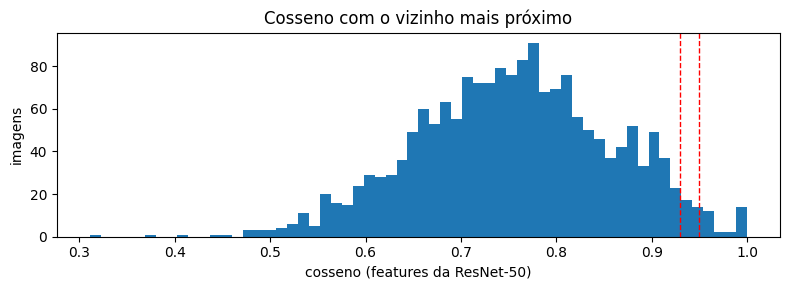

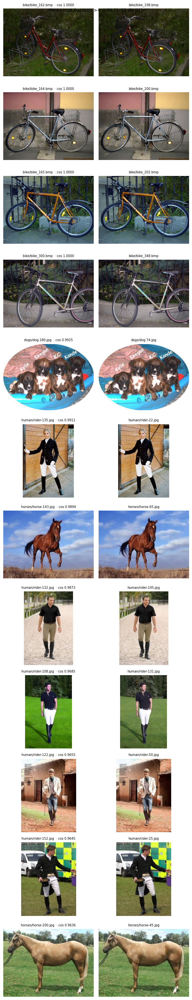

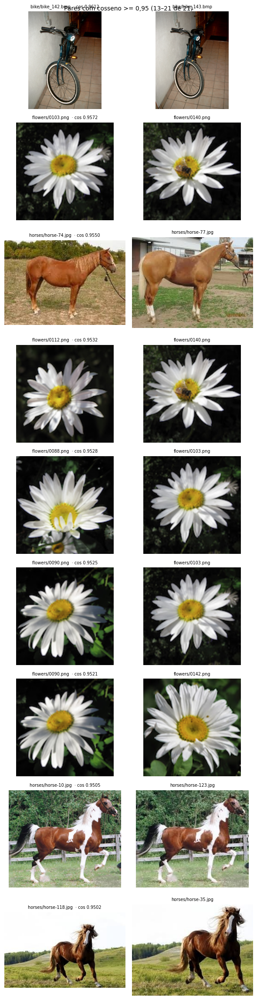

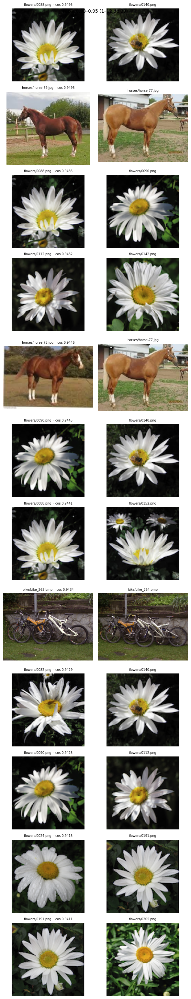

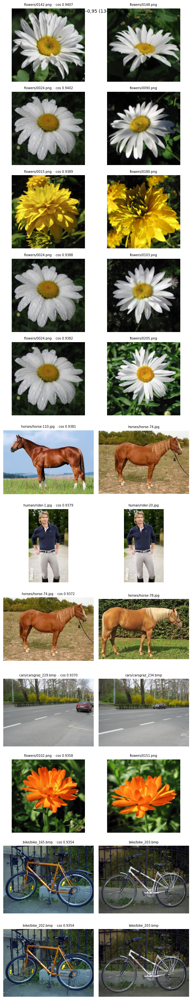

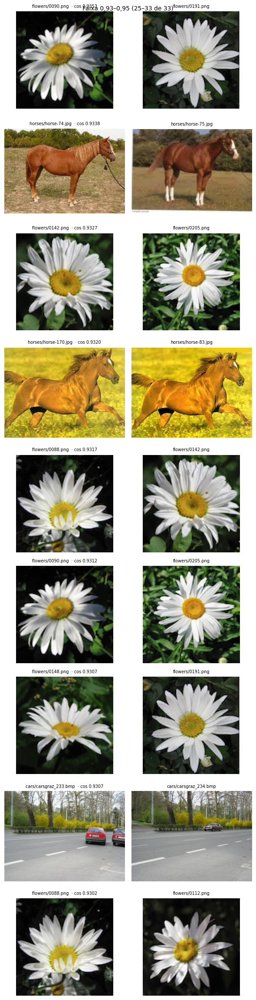

In [13]:
import numpy as np
import torch.nn.functional as F

# Quase-duplicatas no corpus inteiro (o md5 só pega cópias byte a byte): cosseno entre as features de
# todos os pares de imagens. A mesma foto redimensionada ou recomprimida fica com cosseno muito alto.
# Esta célula só MOSTRA a evidência; o critério (limiar + listas de exceções) é fixado na célula
# seguinte por inspeção visual destas figuras, sem usar o desempenho do modelo. Registro: a 1ª execução
# usou um critério provisório (0,95 com uma exceção só); a inspeção das figuras mostrou erros nos dois
# sentidos e o critério foi corrigido por essa evidência (ver markdown da seção).
f_norm = F.normalize(FEATURES_TODAS, dim=-1)
SIM = (f_norm @ f_norm.T).numpy()
np.fill_diagonal(SIM, -1)
vizinho = SIM.max(axis=1)
print("Cosseno com o vizinho mais próximo (cada imagem): percentis 50/90/99 = "
      f"{np.percentile(vizinho, 50):.3f} / {np.percentile(vizinho, 90):.3f} / {np.percentile(vizinho, 99):.3f}")

LIMIAR_INSPECAO = 0.90   # faixa larga, só para olhar
i_sup, j_sup = np.triu_indices(len(imagens), k=1)
mask = SIM[i_sup, j_sup] >= LIMIAR_INSPECAO
PARES = pd.DataFrame({"a": i_sup[mask], "b": j_sup[mask], "cosseno": SIM[i_sup, j_sup][mask]})
PARES["imagem_a"] = imagens["caminho_rel"].values[PARES["a"]]
PARES["imagem_b"] = imagens["caminho_rel"].values[PARES["b"]]
PARES["mesma_classe"] = imagens["classe"].values[PARES["a"]] == imagens["classe"].values[PARES["b"]]
PARES = PARES.sort_values("cosseno", ascending=False).reset_index(drop=True)
for faixa in (0.97, 0.95, 0.93, 0.90):
    print(f"Pares com cosseno >= {faixa}: {(PARES['cosseno'] >= faixa).sum()}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(vizinho, bins=60)
for faixa in (0.93, 0.95):
    ax.axvline(faixa, color="red", ls="--", lw=1)
ax.set(title="Cosseno com o vizinho mais próximo", xlabel="cosseno (features da ResNet-50)", ylabel="imagens")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "quase_duplicatas_histograma.png", dpi=150)
plt.show()


def mostrar_pares(pares, titulo, arquivo, por_figura=12):
    """Pares lado a lado, em figuras de até `por_figura` pares."""
    for ini in range(0, len(pares), por_figura):
        bloco = pares.iloc[ini:ini + por_figura]
        fig, eixos = plt.subplots(len(bloco), 2, figsize=(6, 2.6 * len(bloco)), squeeze=False)
        for linha, (_, r) in enumerate(bloco.iterrows()):
            for coluna, rel in enumerate((r["imagem_a"], r["imagem_b"])):
                eixos[linha, coluna].imshow(carregar_imagem(DIR_DATASET / rel))
                eixos[linha, coluna].set_title(rel.split("/", 1)[1] + (f"  · cos {r['cosseno']:.4f}" if coluna == 0 else ""),
                                               fontsize=7)
                eixos[linha, coluna].axis("off")
        fig.suptitle(f"{titulo} ({ini + 1}–{ini + len(bloco)} de {len(pares)})", fontsize=10)
        plt.tight_layout()
        fig.savefig(DIR_REPORT_ASSETS / f"{arquivo}_{ini // por_figura + 1}.png", dpi=100)
        plt.show()


# Todos os pares >= 0,95 e a faixa logo abaixo (0,93–0,95), onde está a fronteira a decidir
mostrar_pares(PARES[PARES["cosseno"] >= 0.95], "Pares com cosseno >= 0,95", "quase_duplicatas_acima_095")
mostrar_pares(PARES[(PARES["cosseno"] >= 0.93) & (PARES["cosseno"] < 0.95)], "Faixa 0,93–0,95",
              "quase_duplicatas_faixa_093_095")

In [14]:
# Deduplicação antes do split. Critério decidido por INSPEÇÃO VISUAL das figuras acima, sem usar o desempenho
# do modelo: um limiar e duas listas, cada par com o motivo. Pares ligados viram grupos (componentes
# conexos) e de cada grupo fica uma imagem (a primeira em ordem alfabética).
# * acima do limiar, quase todos os pares são a mesma foto (redimensionada/recomprimida);
# * PARES_NAO_DUPLICATAS: acima do limiar, mas fotos diferentes (removê-las perderia dados e, pelo
#   encadeamento dos grupos, juntaria várias margaridas diferentes num grupo só);
# * PARES_DUPLICATAS_EXTRAS: abaixo do limiar, mas a mesma foto ou quadros seguidos da mesma cena
#   (deixá-las em splits diferentes seria vazamento). Baixar o limiar para pegá-las juntaria muitas
#   margaridas e cavalos diferentes (faixa 0,93–0,95).
LIMIAR_QUASE_DUPLICATA = 0.95
PARES_NAO_DUPLICATAS = {   # (motivo)
    ("flowers/0103.png", "flowers/0140.png"),      # margaridas diferentes (uma com abelha no centro)
    ("flowers/0112.png", "flowers/0140.png"),      # margaridas diferentes
    ("flowers/0088.png", "flowers/0103.png"),      # margaridas diferentes
    ("flowers/0090.png", "flowers/0103.png"),      # margaridas diferentes
    ("flowers/0090.png", "flowers/0142.png"),      # margaridas diferentes
    ("horses/horse-74.jpg", "horses/horse-77.jpg"),  # cavalos diferentes (alazão × palomino)
}
PARES_DUPLICATAS_EXTRAS = {  # (motivo)
    ("human/rider-1.jpg", "human/rider-20.jpg"),        # mesma foto (0,938)
    ("horses/horse-170.jpg", "horses/horse-83.jpg"),    # mesma foto (0,932)
    ("bike/bike_263.bmp", "bike/bike_264.bmp"),         # mesma cena, quadros seguidos (0,943)
    ("cars/carsgraz_229.bmp", "cars/carsgraz_234.bmp"),  # mesma cena, quadros seguidos (0,937)
    ("cars/carsgraz_233.bmp", "cars/carsgraz_234.bmp"),  # mesma cena, quadros seguidos (0,931)
}


def _chave(a, b):
    return tuple(sorted((a.split("/", 1)[1], b.split("/", 1)[1])))


nao_dup = {tuple(sorted(par)) for par in PARES_NAO_DUPLICATAS}
ligacoes = PARES[PARES["cosseno"] >= LIMIAR_QUASE_DUPLICATA]
ligacoes = ligacoes[[_chave(a, b) not in nao_dup for a, b in zip(ligacoes["imagem_a"], ligacoes["imagem_b"])]]
idx_por_nome = {rel.split("/", 1)[1]: i for i, rel in enumerate(imagens["caminho_rel"])}
extras = pd.DataFrame([{"a": idx_por_nome[x], "b": idx_por_nome[y]} for x, y in PARES_DUPLICATAS_EXTRAS])
ligacoes = pd.concat([ligacoes[["a", "b"]], extras], ignore_index=True)
print(f"Ligações: {len(ligacoes) - len(extras)} pares >= {LIMIAR_QUASE_DUPLICATA} (fora {len(nao_dup)} exceções) "
      f"+ {len(extras)} pares confirmados abaixo do limiar")

# Componentes conexos (union-find)
pai = list(range(len(imagens)))


def raiz(i):
    while pai[i] != i:
        pai[i] = pai[pai[i]]
        i = pai[i]
    return i


for a, b in zip(ligacoes["a"], ligacoes["b"]):
    pai[raiz(a)] = raiz(b)
imagens["grupo_dup"] = [raiz(i) for i in range(len(imagens))]
tamanhos = imagens["grupo_dup"].value_counts()
grupos = tamanhos[tamanhos > 1]
print(f"Limiar {LIMIAR_QUASE_DUPLICATA}: {len(ligacoes)} pares -> {len(grupos)} grupos de quase-duplicatas "
      f"(grupos por tamanho: {dict((int(t), int(n)) for t, n in grupos.value_counts().sort_index().items())})")

# Nenhum grupo pode misturar classes (seria conflito de rótulo, ex.: horses × human)
classes_por_grupo = imagens.groupby("grupo_dup")["classe"].nunique()
assert (classes_por_grupo == 1).all(), imagens[imagens["grupo_dup"].isin(classes_por_grupo[classes_por_grupo > 1].index)]

manter = imagens.sort_values("caminho_rel").drop_duplicates("grupo_dup", keep="first").index.sort_values()
removidas = imagens.drop(index=manter)
print(f"Removidas: {len(removidas)} imagens · por classe: {removidas['classe'].value_counts().to_dict()}")
removidas[["caminho_rel", "classe"]].to_csv(DIR_REPORT_ASSETS / "quase_duplicatas_removidas.csv", index=False)
imagens = imagens.loc[manter].copy()
imagens["idx_feat"] = imagens.index   # linha correspondente em FEATURES_TODAS
imagens = imagens.reset_index(drop=True)
print(f"Corpus final: {len(imagens)} imagens")

Ligações: 15 pares >= 0.95 (fora 6 exceções) + 5 pares confirmados abaixo do limiar
Limiar 0.95: 20 pares -> 19 grupos de quase-duplicatas (grupos por tamanho: {2: 18, 3: 1})
Removidas: 20 imagens · por classe: {'bike': 6, 'human': 6, 'horses': 5, 'cars': 2, 'dogs': 1}
Corpus final: 1744 imagens


**Corpus e split.** Corpus final: **1.744 imagens** (1.803 da cópia usada − 39 duplicatas exatas por md5,
todas dentro da mesma classe: bike 1, horses 19, human 19 − 20 quase-duplicatas). Split **estratificado
por classe**, 70/15/15, `seed=42`: **1.220 / 262 / 262**. Estratificar mantém a proporção das classes nos
três splits (diferença máxima de 0,4 ponto percentual): com cars e bike bem maiores que as outras, um
sorteio simples poderia deixar uma classe com poucas imagens no teste, e a accuracy por classe ficaria
ainda mais instável (horses e human têm só 27 imagens no teste). Os asserts conferem que nenhuma imagem
(md5) e nenhum grupo de quase-duplicatas aparece em mais de um split. O split fica salvo em
`split_imagens.csv`, versionado no repositório; nas execuções seguintes, o notebook confere se o split
recalculado é idêntico a ele.

In [15]:
from src.dados import SPLIT_TESTE, SPLIT_TREINO, SPLIT_VALIDACAO, dividir_estratificado

# Split estratificado por classe (70/15/15, seed), feito DEPOIS de remover duplicatas exatas e
# quase-duplicatas. Estratificar mantém a proporção das classes nos 3 splits: com cars e bike contra
# ~180–210 nas outras, um sorteio simples poderia deixar uma classe com poucos exemplos no teste e a
# accuracy por classe (R8) instável.
imagens = dividir_estratificado(imagens, FRACOES_SPLIT, SEED)
ORDEM_SPLITS = [SPLIT_TREINO, SPLIT_VALIDACAO, SPLIT_TESTE]

# Sem vazamento: nenhum conteúdo (md5) nem grupo de quase-duplicatas em mais de um split
assert (imagens.groupby("md5")["split"].nunique() == 1).all(), "Mesma imagem em mais de um split"
assert (imagens.groupby("grupo_dup")["split"].nunique() == 1).all(), "Quase-duplicatas em splits diferentes"

tabela_split = pd.crosstab(imagens["classe"], imagens["split"])[ORDEM_SPLITS]
tabela_split.loc["total"] = tabela_split.sum()
display(tabela_split)
display((pd.crosstab(imagens["classe"], imagens["split"], normalize="columns")[ORDEM_SPLITS] * 100).round(1))

# Features de cada split, tiradas de FEATURES_TODAS (sem extrair de novo)
FEATURES = {}
for s in ORDEM_SPLITS:
    idx = torch.tensor(imagens.loc[imagens["split"] == s, "idx_feat"].to_numpy())
    FEATURES[s] = (FEATURES_TODAS[idx], ROTULOS_TODAS[idx])
    assert (FEATURES[s][1].numpy() == [CLASSES.index(c) for c in imagens.loc[imagens["split"] == s, "classe"]]).all()
print({s: tuple(f.shape) for s, (f, _) in FEATURES.items()})

# Split salvo para reprodutibilidade (como o split_lesoes.csv da A1). Se a versão do repositório
# existir, o split recalculado tem que ser idêntico a ela.
COLUNAS_SPLIT = ["caminho_rel", "classe", "md5", "split"]
imagens[COLUNAS_SPLIT].to_csv(DIR_REPORT_ASSETS / "split_imagens.csv", index=False)
SPLIT_VERSIONADO = Path(PROJECT_DIR) / "split_imagens.csv"
if SPLIT_VERSIONADO.exists():
    versionado = pd.read_csv(SPLIT_VERSIONADO)
    recalculado = imagens[COLUNAS_SPLIT].sort_values("caminho_rel").reset_index(drop=True)
    pd.testing.assert_frame_equal(recalculado, versionado.sort_values("caminho_rel").reset_index(drop=True))
    print("Split versionado confere com o recalculado.")
else:
    print(f"Split salvo em {DIR_REPORT_ASSETS / 'split_imagens.csv'} (copiar para {SUBPASTA}/ e versionar).")

split,treino,validacao,teste
classe,,,
bike,250,54,54
cars,292,63,63
cats,142,30,30
dogs,141,30,30
flowers,147,32,31
horses,124,27,27
human,124,26,27
total,1220,262,262


split,treino,validacao,teste
classe,,,
bike,20.5,20.6,20.6
cars,23.9,24.0,24.0
cats,11.6,11.5,11.5
dogs,11.6,11.5,11.5
flowers,12.0,12.2,11.8
horses,10.2,10.3,10.3
human,10.2,9.9,10.3


{'treino': (1220, 2048), 'validacao': (262, 2048), 'teste': (262, 2048)}
Split versionado confere com o recalculado.


## Treino do head (R6)

Um único treino, só do head, com a configuração fixada antes de ver o teste (`CONFIG_TREINO`, na célula
de configuração):
- **Adam**, lr 1e-3, weight decay 1e-4, 40 épocas, lotes de 64, sobre as features em cache;
- **seleção do melhor modelo pela menor val_loss**, guardando o estado com `deepcopy`;
- **pesos de classe "balanced"** (n_treino / (n_classes × n_treino_da_classe)), contados **só no
  treino**: de 0,60 (cars) a 1,41 (horses e human). O desbalanceamento é leve (~2,4×), e o teste tem a
  mesma proporção do treino; os pesos evitam que as classes menores, horses e human (justamente o par
  com risco de confusão), pesem menos na loss. Como só há um treino, essa decisão foi tomada antes, por
  argumento, e não comparando as duas opções. A balanced accuracy é reportada junto com a global para a
  leitura não depender dessa escolha.

In [16]:
import copy

from torch.utils.data import DataLoader, TensorDataset

# Treino do head = o próprio modelo.fc (trocado e verificado acima), sobre as features em cache.
# Configuração em CONFIG_TREINO (célula de configuração), idêntica à da 1ª execução.
head = modelo.fc
x_treino, y_treino = FEATURES[SPLIT_TREINO]
x_val, y_val = FEATURES[SPLIT_VALIDACAO]
gerador = torch.Generator().manual_seed(SEED)   # ordem dos lotes reprodutível
loader_treino = DataLoader(TensorDataset(x_treino, y_treino), batch_size=CONFIG_TREINO["tamanho_lote"],
                           shuffle=True, generator=gerador)
loader_val = DataLoader(TensorDataset(x_val, y_val), batch_size=CONFIG_TREINO["tamanho_lote"], shuffle=False)

# Pesos de classe "balanced", contados SÓ no treino (como qualquer coisa "ajustada" nos dados)
n_por_classe_treino = torch.bincount(y_treino, minlength=len(CLASSES)).float()
pesos_classe = len(y_treino) / (len(CLASSES) * n_por_classe_treino)
print("Pesos de classe (treino):", {c: round(float(w), 3) for c, w in zip(CLASSES, pesos_classe)})

criterio = nn.CrossEntropyLoss(weight=pesos_classe.to(DEVICE))
otimizador = torch.optim.Adam(head.parameters(), lr=CONFIG_TREINO["lr"], weight_decay=CONFIG_TREINO["weight_decay"])
assert {id(p) for g in otimizador.param_groups for p in g["params"]} == {id(p) for p in head.parameters()}


def passar_epoca(loader, treinar: bool):
    """Loss média e accuracy de uma época (treino com gradiente ou validação sem)."""
    head.train(treinar)
    soma_loss, acertos, total = 0.0, 0, 0
    with torch.set_grad_enabled(treinar):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = head(x)
            loss = criterio(logits, y)
            if treinar:
                otimizador.zero_grad()
                loss.backward()
                otimizador.step()
            soma_loss += loss.item() * len(y)
            acertos += (logits.argmax(1) == y).sum().item()
            total += len(y)
    return soma_loss / total, acertos / total


historico = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
melhor_val_loss, melhor_epoca, melhor_estado = float("inf"), None, None
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
_t0 = time.perf_counter()
for epoca in range(1, CONFIG_TREINO["epocas"] + 1):
    tl, ta = passar_epoca(loader_treino, treinar=True)
    vl, va = passar_epoca(loader_val, treinar=False)
    for chave, valor in zip(historico, (tl, ta, vl, va)):
        historico[chave].append(valor)
    if vl < melhor_val_loss:
        # deepcopy: state_dict().copy() só copiaria o dicionário, e os tensores continuariam ligados aos
        # parâmetros que o Adam atualiza no lugar (o "melhor" seria sempre o da última época)
        melhor_val_loss, melhor_epoca, melhor_estado = vl, epoca, copy.deepcopy(head.state_dict())
    if epoca == 1 or epoca % 5 == 0:
        print(f"Época {epoca:02d}/{CONFIG_TREINO['epocas']} | treino: loss {tl:.4f}, acc {ta:.2%} | "
              f"validação: loss {vl:.4f}, acc {va:.2%}")
TEMPOS.append({"etapa": "treino do head", "segundos": round(time.perf_counter() - _t0, 1), **pico_vram_etapa()})

head.load_state_dict(melhor_estado)
head.eval()
torch.save(modelo.state_dict(), DIR_OUTPUTS / "melhor_modelo.pt")
print(f"\nMelhor época: {melhor_epoca} (val_loss {melhor_val_loss:.4f}, val_acc {historico['val_acc'][melhor_epoca - 1]:.2%})")

Pesos de classe (treino): {'bike': 0.697, 'cars': 0.597, 'cats': 1.227, 'dogs': 1.236, 'flowers': 1.186, 'horses': 1.406, 'human': 1.406}
Época 01/40 | treino: loss 1.2220, acc 79.75% | validação: loss 0.5723, acc 98.47%
Época 05/40 | treino: loss 0.1005, acc 99.67% | validação: loss 0.0966, acc 99.62%
Época 10/40 | treino: loss 0.0424, acc 99.92% | validação: loss 0.0495, acc 99.62%
Época 15/40 | treino: loss 0.0242, acc 99.92% | validação: loss 0.0340, acc 99.62%
Época 20/40 | treino: loss 0.0159, acc 100.00% | validação: loss 0.0266, acc 99.62%
Época 25/40 | treino: loss 0.0114, acc 100.00% | validação: loss 0.0221, acc 99.62%
Época 30/40 | treino: loss 0.0087, acc 100.00% | validação: loss 0.0193, acc 99.62%
Época 35/40 | treino: loss 0.0069, acc 100.00% | validação: loss 0.0173, acc 99.62%
Época 40/40 | treino: loss 0.0056, acc 100.00% | validação: loss 0.0159, acc 99.62%

Melhor época: 40 (val_loss 0.0159, val_acc 99.62%)


### Curvas de treino (R9)

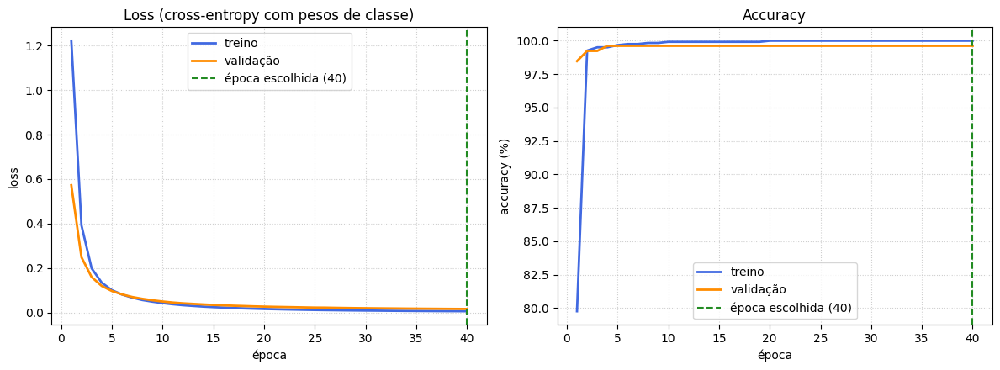

Accuracy de validação máxima: 99.62%, atingida pela primeira vez na época 4


In [17]:
# Curvas de loss e accuracy por época (treino × validação), com a época escolhida marcada.
# A loss é a cross-entropy com os pesos de classe; na accuracy de validação, 1 imagem = 0,38 pp.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
epocas = range(1, len(historico["train_loss"]) + 1)

ax1.plot(epocas, historico["train_loss"], label="treino", color="royalblue", lw=2)
ax1.plot(epocas, historico["val_loss"], label="validação", color="darkorange", lw=2)
ax1.set(title="Loss (cross-entropy com pesos de classe)", xlabel="época", ylabel="loss")

ax2.plot(epocas, [100 * a for a in historico["train_acc"]], label="treino", color="royalblue", lw=2)
ax2.plot(epocas, [100 * a for a in historico["val_acc"]], label="validação", color="darkorange", lw=2)
ax2.set(title="Accuracy", xlabel="época", ylabel="accuracy (%)")

for ax in (ax1, ax2):
    ax.axvline(melhor_epoca, color="forestgreen", ls="--", label=f"época escolhida ({melhor_epoca})")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend()
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "curvas_treino.png", dpi=150)
plt.show()

melhor_val_acc = max(historico["val_acc"])
primeira = historico["val_acc"].index(melhor_val_acc) + 1
print(f"Accuracy de validação máxima: {melhor_val_acc:.2%}, atingida pela primeira vez na época {primeira}")

**Leitura das curvas.**
- **Convergência rápida:** a validação chega a **98,5% na 1ª época** e a 99,62% (1 erro em 262) na 4ª.
  Na 1ª época, a validação aparece melhor que o treino porque as métricas de treino são a média ao longo
  da época, com o head ainda aleatório no início, enquanto a validação é medida no fim.
- **Platô na accuracy:** a partir daí, nas épocas registradas até a 40, a accuracy de validação fica em 99,62%. Cada imagem vale
  0,38 ponto percentual, então a curva está saturada e não informa mais nada.
- **A val_loss continua caindo** (de 0,097 na época 5 para 0,016 na 40) sem mudar nenhuma predição: o head
  fica mais **confiante** nos acertos, não mais preciso. A loss mostrada é a cross-entropy com os pesos de
  classe.
- **Sem sinal de overfitting:** a val_loss não sobe. O treino em 100% a partir dos registros da época 20, com 14 mil
  parâmetros sobre features quase linearmente separáveis, é o esperado.
- **Melhor época = 40** (a última): o critério de seleção nunca precisou voltar a uma época anterior. Isso
  não quer dizer que 40 seja o ótimo, só que, dentro do orçamento fixado antes, a val_loss ainda caía.

## Avaliação no teste (R7, R8)

O teste é avaliado no modelo escolhido pela validação, e nenhuma decisão de treino foi tomada a partir
dele. O modelo foi treinado e avaliado em duas execuções: a segunda veio da correção do critério de
quase-duplicatas e de bugs do treino, com a mesma configuração (ver "1ª × 2ª execução", na análise). Os
outputs salvos são de uma reexecução de verificação da versão entregue (tag `a3-entrega`): mesmo código,
mesmo split (conferido com o CSV versionado) e resultado idêntico ao da 2ª execução, sem nenhuma decisão
tomada a partir dela.

In [18]:
from scipy.stats import binomtest
from sklearn.metrics import balanced_accuracy_score


@torch.inference_mode()
def prever(features: torch.Tensor):
    """Probabilidades (N, n_classes) do head sobre features já extraídas."""
    head.eval()
    return torch.softmax(head(features.to(DEVICE)), dim=1).cpu()


def ic95(acertos: int, total: int):
    """Intervalo de confiança de 95% (Clopper-Pearson) de uma proporção."""
    ic = binomtest(acertos, total).proportion_ci(confidence_level=0.95, method="exact")
    return ic.low, ic.high


# Teste: usado uma única vez, no modelo escolhido pela validação
x_teste, y_teste = FEATURES[SPLIT_TESTE]
probs_teste = prever(x_teste)
y_true = y_teste.numpy()
y_pred = probs_teste.argmax(1).numpy()
acertos = int((y_pred == y_true).sum())
baixo, alto = ic95(acertos, len(y_true))
print(f"Accuracy global no teste: {acertos}/{len(y_true)} = {acertos / len(y_true):.2%} "
      f"(IC 95%: {baixo:.1%}–{alto:.1%})")
print(f"Balanced accuracy (média das accuracies por classe): {balanced_accuracy_score(y_true, y_pred):.2%}")

Accuracy global no teste: 261/262 = 99.62% (IC 95%: 97.9%–100.0%)
Balanced accuracy (média das accuracies por classe): 99.74%


,classe,acertos,total,accuracy,ic95_baixo,ic95_alto
0,bike,53,54,98.15%,90.1%,100.0%
1,cars,63,63,100.00%,94.3%,100.0%
2,cats,30,30,100.00%,88.4%,100.0%
3,dogs,30,30,100.00%,88.4%,100.0%
4,flowers,31,31,100.00%,88.8%,100.0%
5,horses,27,27,100.00%,87.2%,100.0%
6,human,27,27,100.00%,87.2%,100.0%


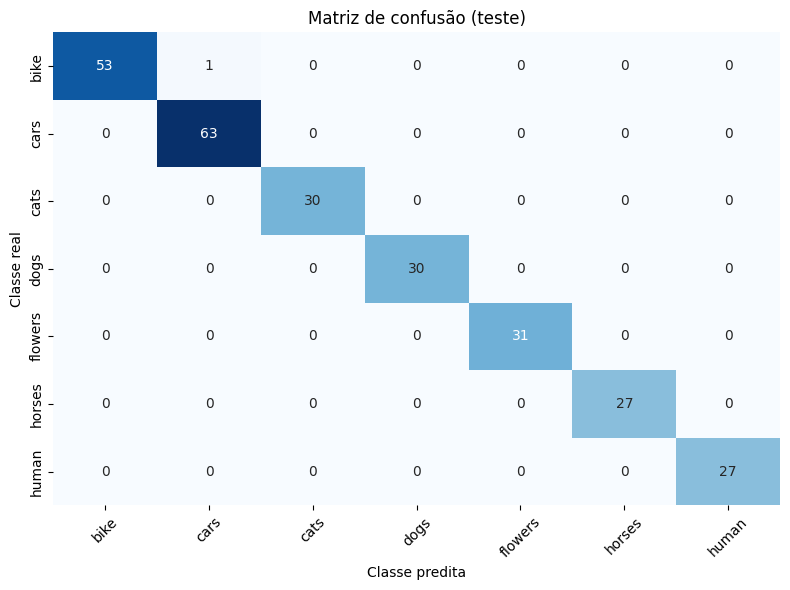

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Accuracy por classe (= recall da classe), com acertos/total e IC: o teste tem 27–63 imagens por
# classe, então 1 erro vale de 1,6 a 3,7 pontos percentuais
cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))
linhas_classe = []
for k, classe in enumerate(CLASSES):
    acertos_k, total_k = int(cm[k, k]), int(cm[k].sum())
    baixo, alto = ic95(acertos_k, total_k)
    linhas_classe.append({"classe": classe, "acertos": acertos_k, "total": total_k,
                          "accuracy": acertos_k / total_k, "ic95_baixo": baixo, "ic95_alto": alto})
df_por_classe = pd.DataFrame(linhas_classe)
df_por_classe.to_csv(DIR_REPORT_ASSETS / "accuracy_por_classe.csv", index=False)
display(df_por_classe.style.format({"accuracy": "{:.2%}", "ic95_baixo": "{:.1%}", "ic95_alto": "{:.1%}"}))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
plt.title("Matriz de confusão (teste)")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DIR_REPORT_ASSETS / "matriz_confusao.png", dpi=150)
plt.show()

Erros no teste: 1


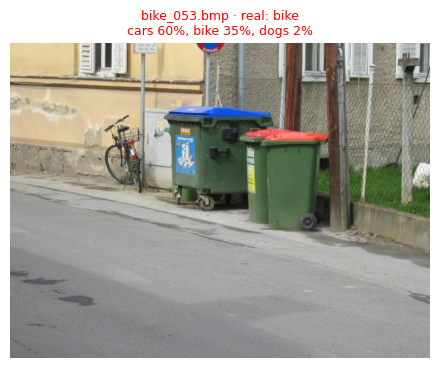

In [20]:
# Erros do teste. As linhas de FEATURES[SPLIT_TESTE] estão na ordem de imagens[split == teste]
# (mesma máscara sobre o mesmo DataFrame): o assert confere os rótulos.
df_teste = imagens[imagens["split"] == SPLIT_TESTE].reset_index(drop=True)
assert (df_teste["classe"].map(CLASSES.index).to_numpy() == y_true).all()
erros_idx = np.where(y_pred != y_true)[0]
print(f"Erros no teste: {len(erros_idx)}")
mostrar = erros_idx[:12]   # no máximo 12 na figura
if len(mostrar):
    fig, eixos = plt.subplots(1, len(mostrar), figsize=(4.5 * len(mostrar), 4.5), squeeze=False)
    for col, i in enumerate(mostrar):
        r = df_teste.iloc[i]
        top3 = probs_teste[i].topk(3)
        texto_top3 = ", ".join(f"{CLASSES[k]} {v:.0%}" for v, k in zip(top3.values.tolist(), top3.indices.tolist()))
        eixos[0, col].imshow(carregar_imagem(r["caminho"]))
        eixos[0, col].set_title(f"{r['arquivo']} · real: {r['classe']}\n{texto_top3}", fontsize=9, color="red")
        eixos[0, col].axis("off")
    plt.tight_layout()
    plt.savefig(DIR_REPORT_ASSETS / "erros_teste.png", dpi=150)
    plt.show()

**Leitura dos resultados.**

### Accuracy e intervalos de confiança

- **Global:** 261/262 = **99,62%** (IC 95% de Clopper-Pearson: 97,9%–100%). A balanced accuracy
  (99,74%) mostra que o desbalanceamento entre as classes não está escondendo erros.
- **Por classe:** seis das sete classes acertaram tudo, mas com 27 a 63 imagens por classe o limite
  inferior do IC vai de **87,2%** (horses e human, 27/27) a **94,3%** (cars, 63/63). O teste é pequeno
  demais para distinguir 98% de 100% ou para ranquear as classes: um erro vale 0,38 ponto percentual na
  accuracy global e 1,9 em bike.

### O único erro

`bike_053.bmp` foi classificada como **cars** (60%), com **bike** em segundo lugar (35%). É uma cena de
rua com uma bicicleta pequena encostada na parede, ao lado de lixeiras, **sem nenhum carro**. A hipótese
mais provável é que o modelo tenha respondido ao **contexto** (rua) e não ao objeto. O erro também ficou
**entre as duas classes que vêm da mesma fonte** (cenas de rua de Graz, BMP 640×480), justamente onde
as pistas de formato e de origem não ajudam a separar as classes.

### Por que a accuracy é tão alta: duas explicações compatíveis

1. **Domínio próximo do ImageNet-1K.** O ImageNet já tem classes de bicicleta, vários tipos de carro,
   dezenas de raças de cão e de gato, margarida e cavalo. Evidência: a validação chegou a **98,5% já na
   1ª época**, com um head linear de 14.343 parâmetros, ou seja, as features do backbone congelado já
   separam as sete classes quase linearmente.
2. **Atalhos de formato e fonte.** Cada classe tem uma assinatura técnica (EDA): bike e cars em BMP
   640×480, flowers em PNG 128×128 (ampliadas para 232 px e, por isso, borradas), as demais em JPG. Este
   experimento não descarta que parte do acerto venha daí. O único erro, entre as duas classes da mesma
   fonte, é coerente com essa hipótese. O teste para separar as duas explicações está proposto no R10.

### Ressalvas

- Pode haver vazamento residual entre quadros das sequências de Graz (ver "Vazamento residual", na
  análise).
- A 1ª execução, com o critério provisório de quase-duplicatas, teve o mesmo resultado (261/262, o mesmo
  erro em `bike_053`); ver "1ª × 2ª execução". Os números desta seção são da reexecução de verificação,
  idênticos aos da 2ª execução.

## Análise e propostas de melhoria (R10–R14)

### Melhorias que seriam testadas e por quê (R10)

Com 99,62% e um erro, há pouco a ganhar em accuracy. O que os resultados pedem é verificar **de onde vem**
o desempenho.

1. **Testar o atalho de formato e fonte.** Recomprimir todas as imagens como JPEG, com a mesma qualidade
   e a mesma resolução, extrair as features de novo e reavaliar **o mesmo head** (sem retreinar e sem
   usar o resultado para escolher nada). Uma queda grande indicaria que parte do acerto vinha da fonte,
   e não do conteúdo.
2. **Split por grupo/cena para bike e cars.** As imagens de Graz são sequências da mesma rua; agrupar os
   quadros de cada cena e dividir por grupo (`StratifiedGroupKFold`) eliminaria o vazamento residual.
3. **Investigar o contexto no `bike_053`.** Mostrar o que sobra depois do center crop (que corta ~27% da
   largura das imagens 640×480) e, opcionalmente, um mapa de ativação (Grad-CAM). Se a bicicleta estiver
   na borda, a rede viu "rua com lixeiras", contexto típico de cars.
4. **Calibração.** A val_loss caiu até a época 40 sem mudar nenhuma predição da validação: o head ficou
   mais confiante, não mais preciso. Se as probabilidades forem usadas (por exemplo, para rejeitar casos
   duvidosos), vale calibrar na validação (*temperature scaling*).
5. **Fine-tuning da `layer4` (lr ~1e-5), só se o item 1 mostrar perda real.** Com 1.220 imagens de treino
   e 98,5% na 1ª época, o ganho esperado é pequeno e o risco de overfitting cresce. Um head não linear
   (MLP) não se justifica pelos resultados: as features já são quase linearmente separáveis (treino em
   100%), e ele acrescentaria ~1 milhão de parâmetros sem sinal de benefício.

### Estratégias de augmentation para este domínio (R11, R13)

| Estratégia | Benefício | Classes que se beneficiam | Classes que podem ser prejudicadas |
|---|---|---|---|
| **Geométrica:** `RandomHorizontalFlip(p=0.5)` | Robustez a orientação esquerda/direita | Todas | Nenhuma: nenhuma classe tem orientação horizontal definida |
| **Escala:** `RandomResizedCrop(224, scale=(0.8, 1.0))` | Variação de enquadramento e distância da câmera | cats, dogs, horses, flowers (o objeto ocupa o quadro) | **bike e cars**: o objeto às vezes é pequeno na cena (como no `bike_053`), e o crop pode removê-lo e deixar só a rua, reforçando o atalho de contexto. **human**: são cavaleiros, às vezes ao lado do cavalo; o crop pode deixar só o cavalo com o rótulo human (confusão com horses). **flowers**: amplia ainda mais uma imagem de 128 px já ampliada |
| **Cor:** `ColorJitter(brightness=0.2, contrast=0.2)` | Robustez a iluminação, sombra e câmeras diferentes | bike e cars (cenas externas), horses | Risco baixo, porque brilho e contraste não mudam o matiz. Um jitter de **matiz** (`hue`), não incluído, prejudicaria flowers (a cor faz parte da identidade: margarida branca × flores amarelas e laranja) e a pelagem de cães, gatos e cavalos |
| **Formato (específica deste dataset):** recompressão JPEG + reamostragem | Tira a pista de formato (BMP sem perda × JPEG × PNG ampliado) e força o modelo a usar o conteúdo | Todas | flowers: imagens de 128 px já pequenas perdem mais detalhe |
| **Não usar:** flip vertical ou rotação grande | — | — | Cavalos, carros e cavaleiros de cabeça para baixo não existem nas fotos reais (a `bike_034`, girada 90° no dataset, já é ruído) |

**Custo:** hoje as features são extraídas uma vez (~12 s). Com augmentation, cada versão aumentada
precisa passar de novo pelo backbone a cada época: o cache de features deixa de valer e o custo vira
~40 × a extração.

### Normalização (R12, R13)

A entrada é normalizada com a média μ = [0,485; 0,456; 0,406] e o desvio σ = [0,229; 0,224; 0,225] do
ImageNet porque o backbone e as 53 camadas de BatchNorm estão **congelados** com os pesos aprendidos
nessa distribuição. A normalização faz parte do "contrato de entrada" dos pesos, junto com o resize para
232 px e o center crop de 224 (as transforms vêm dos próprios pesos). Com o backbone congelado, nada se
adapta a outra escala de entrada. Nada é calculado nos nossos dados, então não há risco de vazamento.

Recalcular a média e o desvio no nosso dataset (só no treino) é a alternativa. Como são fotos naturais,
os valores provavelmente ficariam próximos dos do ImageNet e o efeito seria pequeno: o motivo para usar os
do pré-treino é de princípio (a distribuição que as camadas congeladas esperam), não um ganho medido.

O que a normalização **não** resolve, por classe:
- **flowers:** as imagens de 128 px são ampliadas para 232 e ficam borradas, um padrão que nenhuma outra
  classe tem;
- **bike e cars:** o center crop corta ~27% da largura das imagens 640×480; um objeto pequeno na borda
  pode sair do quadro;
- **human:** as fotos em retrato perdem parte de cima e de baixo no crop quadrado;
- **todas:** a diferença de formato (JPEG × BMP × PNG) continua presente nos pixels.

### Feature extraction × fine-tuning (R14)

- **Critério:** tamanho do dataset × distância do domínio. Dataset pequeno e domínio próximo do
  pré-treino → feature extraction. Pequeno e distante → feature extraction pode não bastar; fine-tuning
  parcial, com lr baixo e cuidado com overfitting. Grande → fine-tuning (parcial ou completo).
- **Aqui:** 1.220 imagens de treino, de classes que existem no ImageNet. Feature extraction basta:
  14.343 parâmetros treináveis (0,061% dos 23,5 milhões), treino de 2 s e 98,5% de validação já na
  1ª época. Fazer fine-tuning com 1.220 imagens arriscaria overfitting e esquecimento do pré-treino
  (*catastrophic forgetting*) para ganhar, no máximo, uma imagem no teste.
- **Contraste com a A1:** em dermatoscopia, um domínio distante do ImageNet, o ViT treinado do zero
  chegou a F1 macro 0,426 e o ViT pré-treinado com **fine-tuning completo** a 0,745: o pré-treino ajudou,
  mas foi preciso ajustar a rede inteira. Na A3, o domínio próximo dispensa isso.

### 1ª × 2ª execução

| | 1ª execução | 2ª execução (= versão entregue) |
|---|---|---|
| Critério de quase-duplicatas | Provisório: limiar 0,95 com uma exceção | Limiar 0,95 + 6 exceções (fotos diferentes) + 5 pares abaixo do limiar, por inspeção visual |
| Imagens removidas | 20 (bike 5, human 5, horses 5, flowers 4, dogs 1), sendo 5 por engano (4 margaridas e o horse-74); 5 pares de fotos repetidas abaixo do limiar ficaram | 20 (bike 6, human 6, horses 5, cars 2, dogs 1), todas duplicatas confirmadas |
| Split | 1.220 / 262 / 262 | 1.220 / 262 / 262, com composição diferente |
| Treino | `nn.Linear` separado do `modelo.fc`; pesos de classe contados no corpus inteiro; cópia rasa do melhor estado | O próprio `modelo.fc`; pesos contados só no treino; `deepcopy`; **mesma configuração** (`CONFIG_TREINO`) |
| Melhor época | 40 | 40 |
| Validação | 99,24% (2 erros) | 99,62% (1 erro) |
| Teste | 261/262 (`bike_053` → cars) | 261/262 (`bike_053` → cars, 60%) |

**O teste foi avaliado em duas execuções com treinos diferentes**, mais uma reexecução de verificação da
versão entregue (mesmo código e split, resultado idêntico ao da 2ª). Nenhuma decisão de treino foi tomada
a partir dele: a 2ª execução
veio da inspeção visual dos pares de quase-duplicatas e da correção de bugs, com a configuração de treino
idêntica. Os bugs estavam latentes (a melhor época foi a última nas duas execuções, e o head treinado é o
mesmo tipo de camada sobre as mesmas features), por isso o resultado não mudou: a correção tornou o
procedimento correto, não melhorou o número. Os dois testes não são o mesmo conjunto, mas se sobrepõem
muito; o 99,62% repetido não equivale a duas medições independentes.

### Vazamento residual

As imagens de bike e cars vêm de sequências de cenas de rua de Graz. O critério de quase-duplicatas
pegou os quadros mais parecidos (cosseno ≥ 0,95 e cinco pares conferidos visualmente na faixa
0,93–0,95), mas quadros da mesma rua com cosseno mais baixo **podem** ter ficado em splits diferentes;
isso não foi medido. Se acontecer, a accuracy de bike e cars fica otimista, porque o modelo reconhece a
mesma rua, luz e câmera. Um diagnóstico sem treino seria comparar, por classe, o cosseno de cada imagem de
teste com a vizinha mais próxima no treino; a solução é o split por grupo/cena (R10, item 2).

## Apêndice: versões e tempo/memória (R15)

In [21]:
import platform
import resource
from importlib.metadata import version

import sklearn
import torchvision

print(f"Python {platform.python_version()} · torch {torch.__version__} · torchvision {torchvision.__version__} · "
      f"scikit-learn {sklearn.__version__} · kagglehub {version('kagglehub')}")
print(f"numpy {np.__version__} · pandas {pd.__version__} · Pillow {version('pillow')} · "
      f"matplotlib {version('matplotlib')} · seaborn {version('seaborn')} · scipy {version('scipy')}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'nenhuma (CPU)'} · "
      f"SO {platform.system()} {platform.release()}")

# Tempo e memória por etapa (os picos de VRAM são por etapa: o contador é zerado no início de cada uma)
df_tempos = pd.DataFrame(TEMPOS)
df_tempos.to_csv(DIR_REPORT_ASSETS / "tempos_execucao.csv", index=False)
display(df_tempos)
tempo_total = time.perf_counter() - _T_INICIO_NOTEBOOK
pico_ram_gb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6   # ru_maxrss em KB no Linux
print(f"Tempo total do notebook: {tempo_total:.0f} s ({tempo_total / 60:.1f} min)")
print(f"Pico de VRAM: alocada {df_tempos.get('pico_vram_gb', pd.Series(dtype=float)).max()} GB, "
      f"reservada {df_tempos.get('pico_vram_reservada_gb', pd.Series(dtype=float)).max()} GB")
print(f"Pico de RAM do processo: {pico_ram_gb:.1f} GB")

Python 3.13.15 · torch 2.11.0+cu130 · torchvision 0.26.0+cu130 · scikit-learn 1.6.1 · kagglehub 1.0.2
numpy 2.1.3 · pandas 2.2.3 · Pillow 11.3.0 · matplotlib 3.10.0 · seaborn 0.13.2 · scipy 1.16.3
GPU: Tesla T4 · SO Linux 6.6.122+


,etapa,segundos,pico_vram_gb,pico_vram_reservada_gb
0,clone/pull do repositório,2.4,NaN,NaN
1,download do dataset,4.1,NaN,NaN
2,carregamento do backbone,1.5,0.10,0.12
3,extração das features,11.9,0.80,1.25
4,treino do head,2.0,0.11,1.25


Tempo total do notebook: 124 s (2.1 min)
Pico de VRAM: alocada 0.8 GB, reservada 1.25 GB
Pico de RAM do processo: 1.9 GB
